In [3]:
import pandas as pd
import scipy
import numpy as np
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Verdana']
from scipy.optimize import fsolve

## Import einer Kennlinienmessung des Metallkissens

In [8]:
df1 = pd.read_excel (r"C:\Users\A2H67001\LOKAL-TEMP\Aktuell\ERLEDIGT\Kissekräfte_Berechnung\E3613AA bis 3500 N.xls")

In [9]:
# Daten Anzeigen (bei Bedarf)

# df1

In [10]:
data1 = df1.values

h = data1 [:, 6]
F = data1 [:, 7]

# Curve fitting F(h)

In [11]:
# Kennlinienfunktion

def function(x, a, b, c, d):
    return ((a-b*x)*x)/(1-c*x+d*(x**2))

In [12]:
# Parameter für Funktion bestimmen (Mittlere Kennlinie)

popt, _ = curve_fit(function, h, F)
a, b, c, d = popt
F_pred = function(h, a, b, c, d)

print(a,b,c,d)

3.860759919887929 0.2392366617906819 0.2292272561626944 0.013125224027128748


In [13]:
# Mittlere quadratische Abweichung

mse = np.sqrt(mean_squared_error(F, F_pred))
print(mse)

95.49026309807917


# Berechnung verspanntes System

### Eingabe Systemdaten

In [34]:
hv = 10 # Höhe unter Vorspannung; ein Kissen [mm]
Fb = 2500 # Betriebskraft  (symmetrisch Zug-Druck) [N]
A = 383 # Kissenfläche [mm^2]

### Berechnung

In [15]:
# Funktion für h_min

def equation(x):
    
    return [((a-b*x[0])*x[0])/(1-c*x[0]+d*(x[0]**2))-
            ((a-b*(2*hv-x[0]))*(2*hv-x[0]))/(1-c*(2*hv-x[0])+d*((2*hv-x[0])**2))-Fb]

In [49]:
# ACHTUNG: Die Funktion hate mehrere Nullpunkte!!
# Beginnen mit Startwert = hv und wenn Ergebnis nicht auf Kennlinie liegt, Startwert im Bereich von +- 1 variieren
# h_min = fsolve (equation, [Startwert])

h_min = fsolve (equation, [10])

### Berechnete Kissenkräfte und Höhen

In [32]:
print("h_min =", round(float(h_min),2), "mm")

h_min = 9.42 mm


In [29]:
h_max = x = 2*hv - h_min
print("h_max =", round(float(h_max),2), "mm")

h_max = 10.58 mm


In [27]:
x = h_min
F_max = ((a-b*x)*x)/(1-c*x+d*(x**2))

print("F_max =", int(F_max), "N")

F_max = 2820 N


In [26]:
x = h_max
F_min = ((a-b*x)*x)/(1-c*x+d*(x**2))
print("F_min =", int(F_min), "N")

F_min = 320 N


In [25]:
x = hv
Fv = ((a-b*x)*x)/(1-c*x+d*(x**2))
print("Fv =", int(Fv), "N")

Fv = 725 N


### Mittlere Flächenpressung und Flächenpressungsamplitude pro Kissen

In [42]:
F_m = (F_max + F_min)/2
F_a = (F_max - F_min)/2

sigma_m = F_m / A
sigma_a = F_a / A

print("F_m =", int(F_m), "N")
print("F_a =", int(F_a), "N")
print("\n")
print("sigma_m =", round(float(sigma_m),3), "Mpa")
print("sigma_a =", round(float(sigma_a),3), "Mpa")

F_m = 1570 N
F_a = 1249 N


sigma_m = 4.099 Mpa
sigma_a = 3.264 Mpa


### Darstellung

<ipython-input-45-9f52187d2b01>:21: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


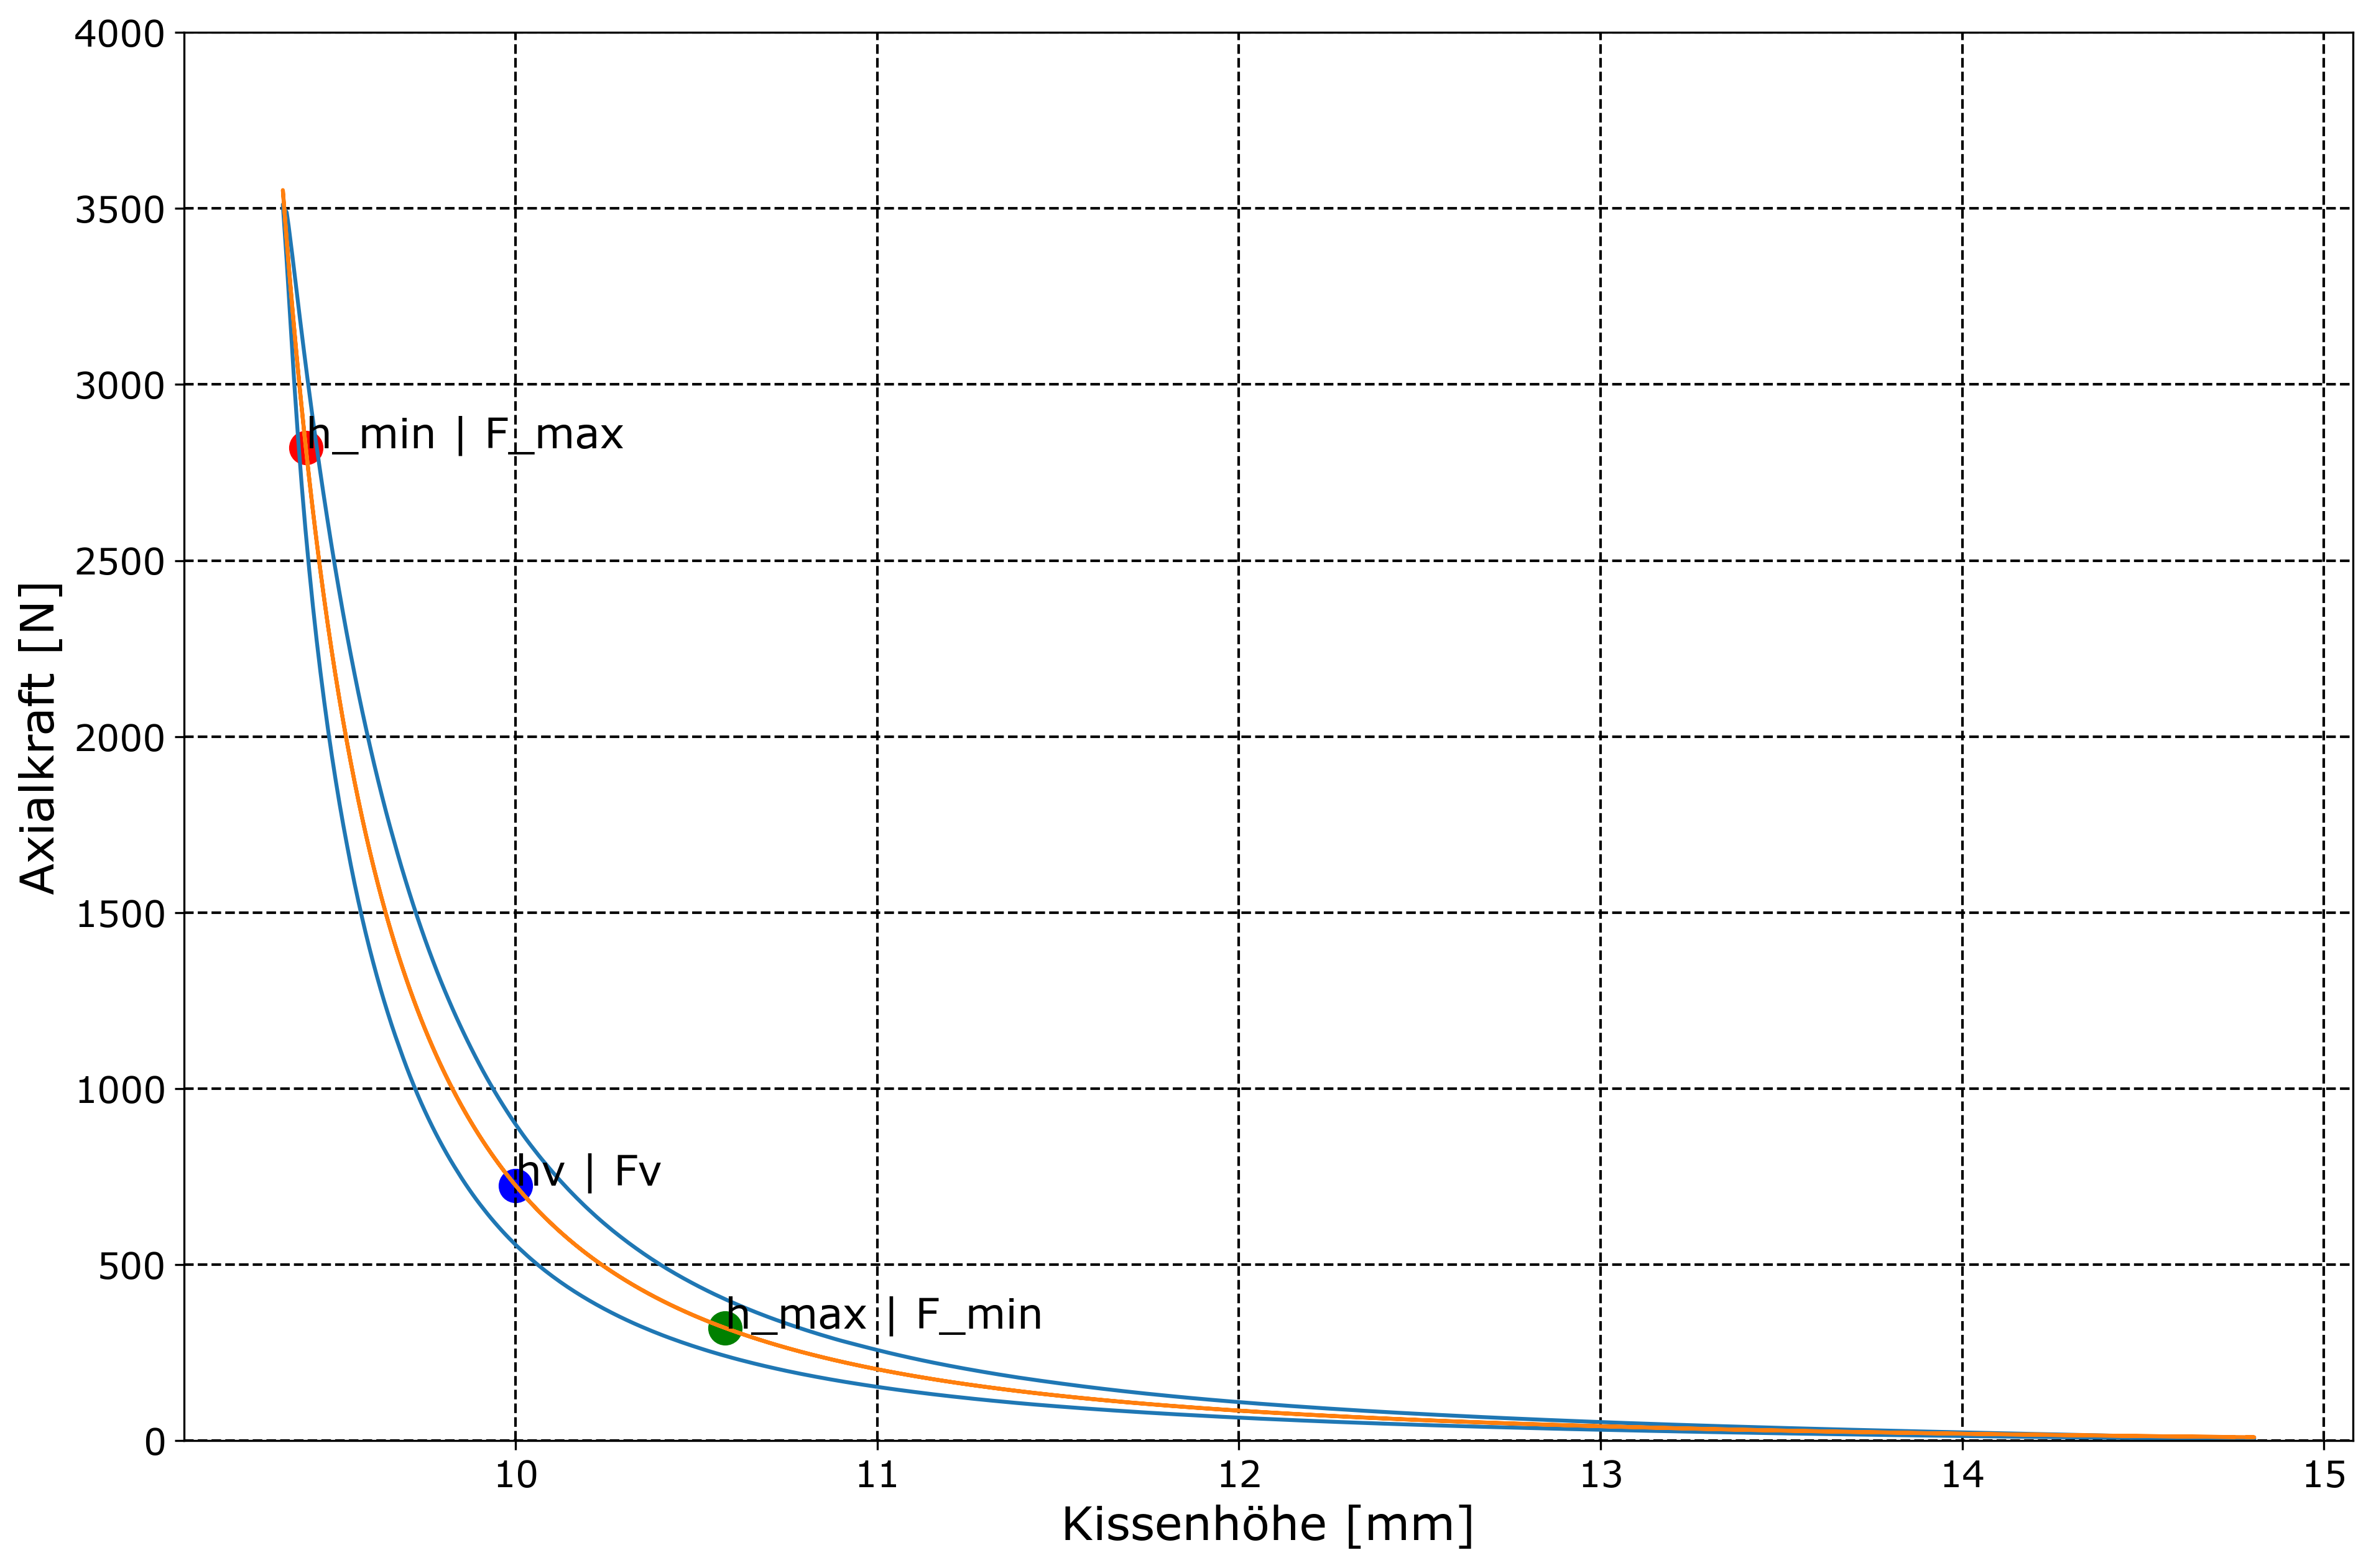

In [45]:
fig, ax = plt.subplots(figsize=(15, 10), dpi=300)   

ax.plot(h, F)
ax.plot(h, F_pred)

ax.scatter(h_max, F_min,150, color ="green")
ax.scatter(h_min, F_max, 150, color ="red")
ax.scatter(hv, Fv, 150, color ="blue")

ax.annotate("h_max | F_min", (h_max, F_min), fontsize=16)
ax.annotate("h_min | F_max", (h_min, F_max), fontsize=16)
ax.annotate("hv | Fv", (hv, Fv), fontsize=16)

ax.set_ylabel('Axialkraft [N]', fontsize=18)
ax.set_xlabel('Kissenhöhe [mm]', fontsize=18)
ax.tick_params(axis='both', labelsize=14)
#plt.xlim((0, 8))
plt.ylim((0, 4000))
plt.grid(True)
plt.grid(color='k', linestyle='--', linewidth=1)
fig.show()

fig.savefig('Verspanntes-System.jpg', dpi= 450)

# Darstellung Nullstellensuche Funktion:

<ipython-input-47-9d474afc9b03>:26: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


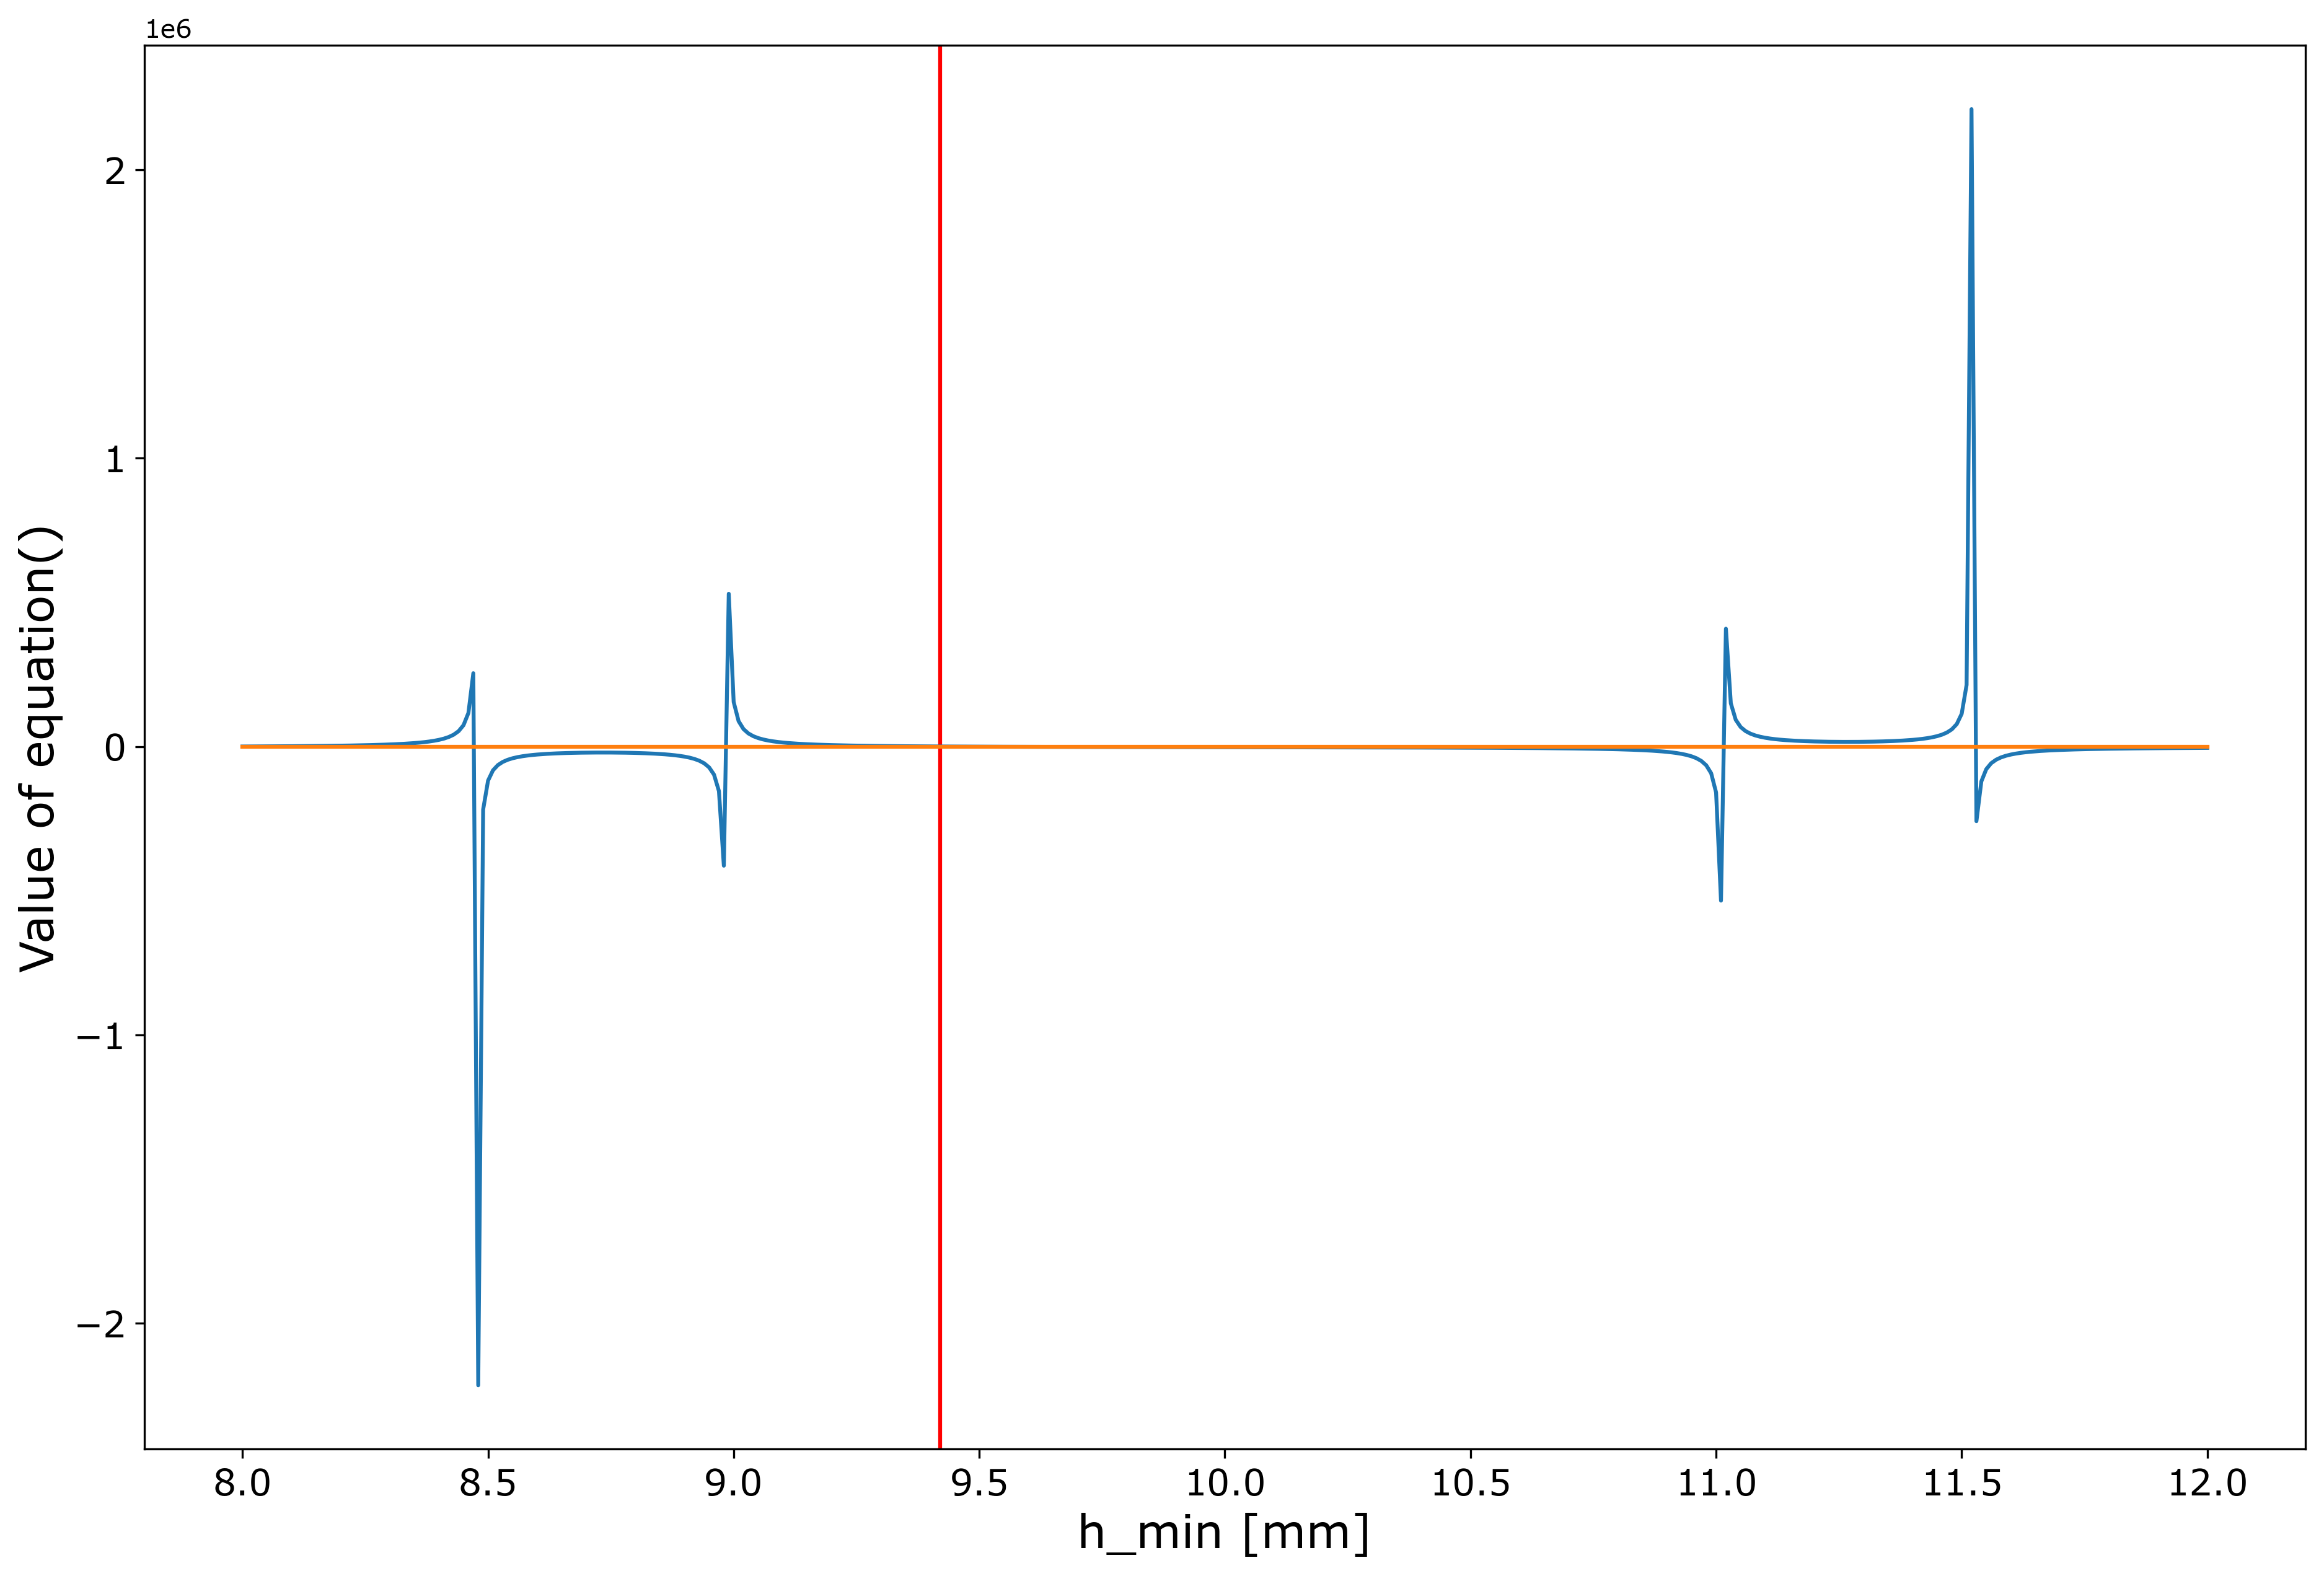

In [47]:
def test(x):
    
    return ((a-b*x)*x)/(1-c*x+d*(x**2))-((a-b*(2*hv-x))*(2*hv-x))/(1-c*(2*hv-x)+d*((2*hv-x)**2))-Fb

graph_x= []
graph_y= []
zero = []

i=8

while i < 12:
    graph_x.append (i)
    graph_y.append (test(i))
    i+=0.01

for i in graph_x:
    zero.append(0)

fig, ax = plt.subplots(figsize=(15, 10), dpi=300)   
ax.axvline(x=9.42, ymin=-3000000, ymax=3000000, color ="red") 
ax.plot (graph_x, graph_y)
ax.plot (graph_x, zero)
ax.set_ylabel('Value of equation()', fontsize=18)
ax.set_xlabel('h_min [mm]', fontsize=18)
ax.tick_params(axis='both', labelsize=14)
fig.show()

#fig.savefig('Nullstellensuche-1.jpg', dpi= 300)

<ipython-input-48-c0d82750ac9a>:11: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


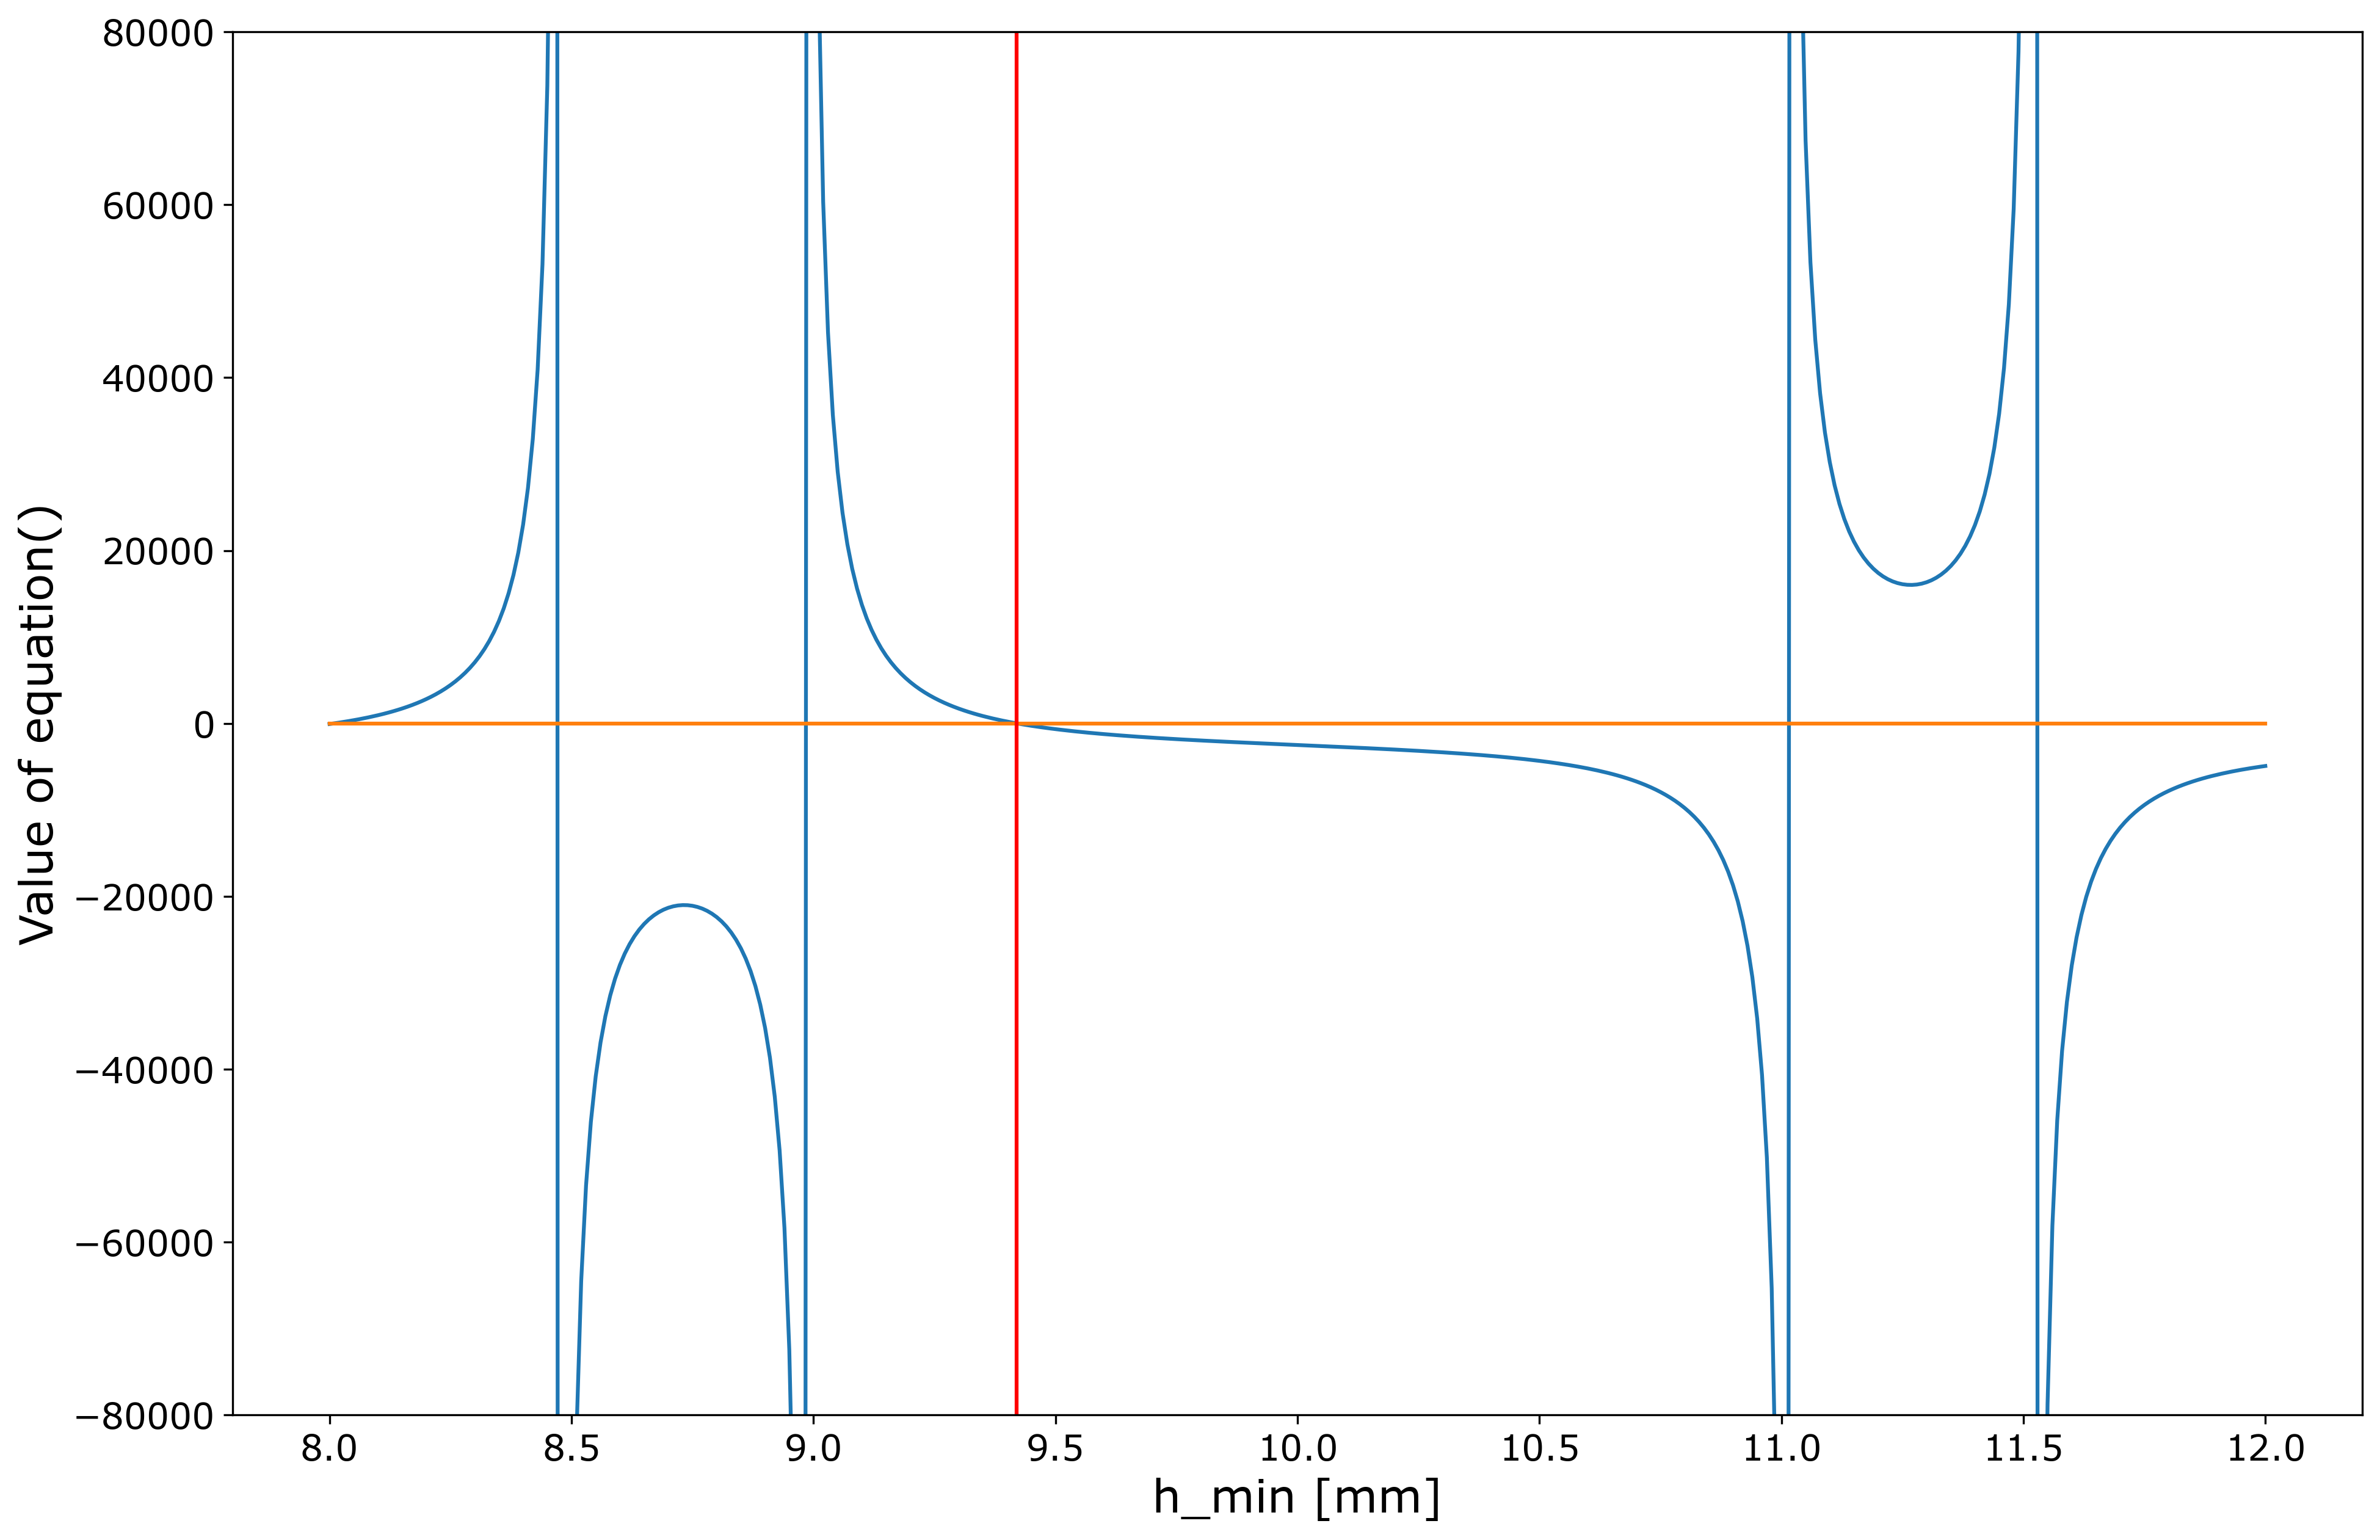

In [48]:
fig, ax = plt.subplots(figsize=(15, 10), dpi=300)  
ax.set_ylabel('Value of equation()', fontsize=18)
ax.set_xlabel('h_min [mm]', fontsize=18)
ax.tick_params(axis='both', labelsize=14)

ax.plot (graph_x, graph_y)
ax.plot (graph_x, zero)
plt.ylim((-80000, 80000))
ax.axvline(x=9.42, ymin=-3000000, ymax=3000000, color ="red") 

fig.show()

#fig.savefig('Nullstellensuche-2.jpg', dpi= 300)

# -- To be continued --
## Unterschiedliche Kissen
## Asymmetrische Belastung
## etc. mit diesem Ansatz möglich